# **Лабораторна робота № 8**

## **Тема. Структура даних граф. Алгоритми на графах**

## **Мета:** засвоїти представлення структури даних граф та основні алгоритми роботи з ними засобами Python. 

## **Виконав:** Гордієнко В.Ю.

### **Завдання 1-2:** Для варіанту, заданого викладачем, задати і візуалізувати граф за допомогою коду, наведеного у цій роботі. Для свого варіанту реалізувати всі алгоритми, згідно з прикладами, наведеними вище. 

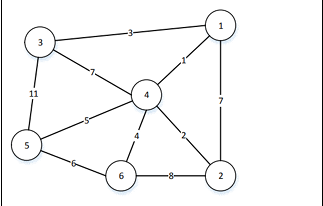

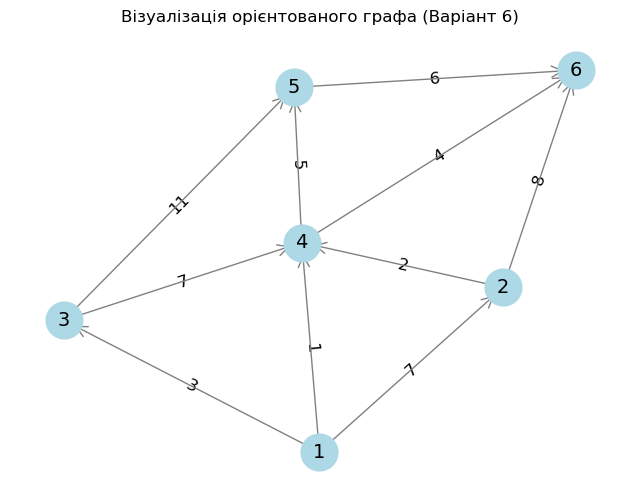

--- Результати обчислень для вершини джерела '1' ---

Дейкстра (найкоротші відстані від 1):
До вершини 1: відстань = 0, шлях = ['1']
До вершини 2: відстань = 7, шлях = ['1', '2']
До вершини 3: відстань = 3, шлях = ['1', '3']
До вершини 4: відстань = 1, шлях = ['1', '4']
До вершини 5: відстань = 6, шлях = ['1', '4', '5']
До вершини 6: відстань = 5, шлях = ['1', '4', '6']

Беллман-Форд (найкоротші відстані від 1):
До вершини 1: відстань = 0, шлях = ['1']
До вершини 2: відстань = 7, шлях = ['1', '2']
До вершини 3: відстань = 3, шлях = ['1', '3']
До вершини 4: відстань = 1, шлях = ['1', '4']
До вершини 5: відстань = 6, шлях = ['1', '4', '5']
До вершини 6: відстань = 5, шлях = ['1', '4', '6']

--- Шляхи між '1' та '6' ---
DFS всі шляхи (1 -> 6): [['1', '2', '4', '5', '6'], ['1', '2', '4', '6'], ['1', '2', '6'], ['1', '3', '4', '5', '6'], ['1', '3', '4', '6'], ['1', '3', '5', '6'], ['1', '4', '5', '6'], ['1', '4', '6']]
BFS всі шляхи (1 -> 6): [['1', '2', '6'], ['1', '4', '6'], ['1', '2', '4

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Граф для варіанту 22
edges_arr = [
    ('1', '2', {'weight': 7}),
    ('1', '3', {'weight': 3}),
    ('1', '4', {'weight': 1}),
    ('2', '4', {'weight': 2}),
    ('2', '6', {'weight': 8}),
    ('3', '4', {'weight': 7}),
    ('3', '5', {'weight': 11}),
    ('4', '5', {'weight': 5}),
    ('4', '6', {'weight': 4}),
    ('5', '6', {'weight': 6})
]

G = nx.DiGraph() 
G.add_edges_from((u, v, w) for u, v, w in edges_arr)

# Візуалізація графа
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=14, font_family='sans-serif')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=12)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray')
plt.title("Візуалізація орієнтованого графа (Варіант 6)")
plt.axis('off')
plt.show()

# Визначаємо початкову та кінцеву вершини
start_node = '1'
end_node = '6'

print(f"--- Результати обчислень для вершини джерела '{start_node}' ---")

# Алгоритм Дейкстри
lengths_dijkstra, paths_dijkstra = nx.single_source_dijkstra(G, start_node)
print(f"\nДейкстра (найкоротші відстані від {start_node}):")
for node in sorted(lengths_dijkstra.keys()):
    print(f"До вершини {node}: відстань = {lengths_dijkstra[node]}, шлях = {paths_dijkstra[node]}")

# Алгоритм Беллмана-Форда
try:
    lengths_bellman = nx.single_source_bellman_ford_path_length(G, start_node)
    paths_bellman = nx.single_source_bellman_ford_path(G, start_node)
    
    print(f"\nБеллман-Форд (найкоротші відстані від {start_node}):")
    for node in sorted(lengths_bellman.keys()):
        print(f"До вершини {node}: відстань = {lengths_bellman[node]}, шлях = {paths_bellman[node]}")
except nx.NetworkXNoPath:
    print(f"\n[Беллман-Форд]: Шлях від вершини {start_node} до деяких вузлів не існує.")


# --- Класичний пошук усіх шляхів без використання yield ---

def find_all_dfs_paths(graph, start, goal):
    res = []
    
    def dfs_helper(current, target, current_path):
        if current == target:
            res.append(current_path)
            return
        
        for neighbor in graph.adj[current].keys():
            if neighbor not in current_path:
                dfs_helper(neighbor, target, current_path + [neighbor])
                
    dfs_helper(start, goal, [start])
    return res

def find_all_bfs_paths(graph, start, goal):
    res = []
    queue = [[start]]
    
    while len(queue) > 0:
        current_path = queue.pop(0) 
        last_node = current_path[-1]
        
        if last_node == goal:
            res.append(current_path)
            continue
            
        for neighbor in graph.adj[last_node].keys():
            if neighbor not in current_path:
                queue.append(current_path + [neighbor])
                
    return res


# Вивід результатів пошуку шляхів
print(f"\n--- Шляхи між '{start_node}' та '{end_node}' ---")
print(f"DFS всі шляхи ({start_node} -> {end_node}):", find_all_dfs_paths(G, start_node, end_node))
print(f"BFS всі шляхи ({start_node} -> {end_node}):", find_all_bfs_paths(G, start_node, end_node))

## **Висновок:** після виконання лабораторної роботи я засвоїв представлення структури даних граф та основні алгоритми роботи з ними засобами Python. 

### **Контрольні питання:**
1. Що таке граф у термінах теорії графів? Наведіть приклади реальних ситуацій, де можна застосовувати графи.

Граф — це математична структура, що складається з множини вершин (вузлів) та ребер (зв'язків між ними). Реальні приклади застосування: соціальні мережі (користувачі — це вершини, дружба — ребра), транспортні системи (міста — вершини, автошляхи — ребра) та комп'ютерні мережі (сервери — вершини, лінії передачі даних — ребра).

2. Які основні види графів існують? Наведіть відмінності між орієнтованими і неорієнтованими графами.

Основні види: орієнтовані та неорієнтовані. Головна відмінність: в орієнтованому графі зв'язок між вершинами $A$ і $B$ має напрямок ($A \to B$ не обов'язково означає $B \to A$), тоді як у неорієнтованому зв'язок є двостороннім. Також існують зважені графи, де ребра мають певну «вагу» або ціну.

3. Як можна представити граф у пам’яті комп'ютера? Опишіть структури даних, які використовуються для зберігання графів.

Графи зазвичай зберігають двома способами:

Матриця суміжності: таблиця $N \times N$, де $1$ позначає наявність зв'язку, а $0$ — його відсутність. Це зручно для щільних графів.

Список суміжності: масив, де для кожної вершини вказано список її сусідів. Це оптимально для розріджених графів.

4. Як працює алгоритм пошуку в ширину (BFS) на графах? Наведіть приклади ситуацій, де застосовується цей алгоритм.

BFS обходить граф рівнями: спочатку відвідується стартова вершина, потім усі її сусіди, потім «сусіди сусідів» і так далі (використовується черга). Цей алгоритм застосовується для знаходження найкоротшого шляху в незважених графах або в задачах про пошук у станах (наприклад, розв'язання головоломок).

5. Що таке алгоритм пошуку в глибину (DFS) на графах? Як він відрізняється від BFS? Дайте приклади задач, де використовується DFS.

DFS рухається максимально глибоко по одній гілці графа, поки не дійде до кінця, після чого повертається назад (використовується стек або рекурсія). На відміну від BFS, він не гарантує найкоротший шлях, але ефективніший для завдань на кшталт виявлення циклів, перевірки зв'язності або топологічного сортування.

6. Опишіть алгоритм Дейкстри для пошуку найкоротшого шляху в графі. Які умови повинні виконуватися для успішної роботи цього алгоритму?

Це алгоритм пошуку найкоротшого шляху від однієї вершини до всіх інших у зваженому графі. Він працює шляхом ітеративного вибору вершини з найменшою відомою відстанню від старту. Головна умова успішної роботи — всі ваги ребер повинні бути невід'ємними ($w \ge 0$), оскільки алгоритм не розрахований на роботу з від'ємними вагами.